In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from PIL import Image
import matplotlib.pyplot as plt

import cv2
import os
import time

In [3]:
DATA_DIR = "data/processed_data"
IMG_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.001
BATCH_SIZE = 32
TEST_SPLIT = 0.2
MODEL_PATH = "models/facial_emotion_detection_v1.pth"

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3,
                      out_channels=16,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16,
                      out_channels=32,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=32,
                      out_channels=64,
                      kernel_size=3,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4096, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(in_features=128,
                      out_features=num_classes)
        )
        
    def forward(self, x):
        #return self.classifier(self.features(x))
        x = self.features(x)
        x = self.classifier(x)
        return x

In [21]:
train_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(size=(IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [22]:
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transform)
len(full_dataset)

49776

In [23]:
class_names = full_dataset.classes
num_classes = len(class_names)
class_names

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [10]:
test_count = int(len(full_dataset) * TEST_SPLIT)
train_count = len(full_dataset) - test_count

train, test = random_split(dataset=full_dataset, lengths=[train_count, test_count])

In [11]:
test.dataset.transform = test_transform

In [12]:
train_loader = DataLoader(dataset=train, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count())
test_loader = DataLoader(dataset=test, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count())

In [13]:
model_0 = CNN(num_classes=num_classes)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(params=model_0.parameters(), lr=LEARNING_RATE)

In [18]:
def train():
    best_acc = 0.0
    results = {"train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": []}
    
    for epoch in range(1, EPOCHS + 1):
        model_0.train()
        train_loss = 0
        train_correct = 0
        total = 0
        t0 = time.time()
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model_0(images)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            total += images.size(0)
            
        model_0.eval()
        test_loss = 0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model_0(images)
                loss = loss_fn(outputs, labels)
                
                test_loss += loss.item() * images.size(0)
                preds = outputs.argmax(dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += images.size(0)
        
        train_loss /= total
        train_acc = train_correct / total
        test_loss /= test_total
        test_acc = test_correct / test_total
        t1 = time.time()
        elapsed = t1 - t0 
        print(f"EPOCH {epoch}/{EPOCHS} | train_loss = {train_loss:.3f} | train_acc = {train_acc:.3f} | test_loss = {test_loss:.3f} | test_acc = {test_acc:.3f} | time = {elapsed:.1f}s")
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save({
                "model_state": model_0.state_dict(),
                "class_names": class_names,
                "img_size": IMG_SIZE
            },
            MODEL_PATH)
            print(f"Saving the model with the best test accuracy: {best_acc:.3f} to {MODEL_PATH}")
        
    print("Training completed")
    return results

In [15]:
def inference():
    checkpoint = torch.load(MODEL_PATH)
    model_0.load_state_dict(checkpoint["model_state"])
    model_0.eval()
    class_names = checkpoint["class_names"]
    
    print("Webcam starting... press q to quit")
    webcam = cv2.VideoCapture(0)
    if not webcam.isOpened():
        print("webcam error")
        return
    
    while True:
        ret, frame = webcam.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resize_img = Image.fromarray(rgb).resize((IMG_SIZE, IMG_SIZE))
        tensor = transforms.functional.to_tensor(resize_img)
        tensor = transforms.functional.normalize(tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        tensor = tensor.unsqueeze(0)
        
        with torch.no_grad():
            out = model_0(tensor)
            probs = torch.nn.functional.softmax(out, dim=1)
            top_prob, prob_idx = torch.max(probs, dim=1)
            label = class_names[prob_idx.item()]
            conf = top_prob.item()
        
        cv2.putText(frame, f"{label} {conf:.2f}", (10, 30), cv2.FONT_HERSHEY_COMPLEX, 1.0, (0, 255, 0), 2)
        cv2.imshow("Emotion Detector (q to quit)", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
        
    webcam.release()
    cv2.destroyAllWindows()

In [37]:
train()

EPOCH 1/20 | train_loss = 0.789 | train_acc = 0.697 | test_loss = 0.969 | test_acc = 0.647 | time = 337.0s
Saving the model with the best test accuracy: 0.647 to models/facial_emotion_detection_v0.pth
EPOCH 2/20 | train_loss = 0.776 | train_acc = 0.704 | test_loss = 0.966 | test_acc = 0.646 | time = 234.8s
EPOCH 3/20 | train_loss = 0.764 | train_acc = 0.707 | test_loss = 0.982 | test_acc = 0.647 | time = 235.2s
EPOCH 4/20 | train_loss = 0.752 | train_acc = 0.708 | test_loss = 0.973 | test_acc = 0.647 | time = 232.3s
EPOCH 5/20 | train_loss = 0.740 | train_acc = 0.719 | test_loss = 0.981 | test_acc = 0.647 | time = 238.5s
EPOCH 6/20 | train_loss = 0.726 | train_acc = 0.721 | test_loss = 0.986 | test_acc = 0.650 | time = 232.9s
Saving the model with the best test accuracy: 0.650 to models/facial_emotion_detection_v0.pth
EPOCH 7/20 | train_loss = 0.718 | train_acc = 0.724 | test_loss = 0.992 | test_acc = 0.644 | time = 233.3s
EPOCH 8/20 | train_loss = 0.710 | train_acc = 0.724 | test_loss

In [38]:
inference()

Webcam starting... press q to quit


In [ ]:
model_0_results = train() # v1

In [20]:
def plot_loss_curves(results):
    loss = results["train_loss"]
    test_loss = results["test_loss"]
    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

In [ ]:
plot_loss_curves(model_0_results)

### Trained using data aug. acc - 65.9

In [4]:
class CNNv2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3,
                      out_channels=16,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(in_channels=16,
                      out_channels=32,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=32,
                      out_channels=64,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64,
                      out_channels=64,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=64,
                      out_channels=64,
                      kernel_size=3,
                      padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4096, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(in_features=128,
                      out_features=num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
model_1 = CNNv2(num_classes=7)

checkpoint = torch.load(
    "models/facial_emotion_detection_v6.pth",
    map_location=torch.device("cpu")
)

model_1.load_state_dict(checkpoint["model_state"])

model_1.eval()

CNNv2(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [13]:
def inferencev2():
    checkpoint = torch.load("models/facial_emotion_detection_v6.pth",  map_location=torch.device("cpu"))
    model_1.load_state_dict(checkpoint["model_state"])
    model_1.eval()
    class_names = checkpoint["class_names"]
    
    print("Webcam starting... press q to quit")
    webcam = cv2.VideoCapture(0)
    if not webcam.isOpened():
        print("webcam error")
        return
    
    while True:
        ret, frame = webcam.read()
        if not ret:
            break
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resize_img = Image.fromarray(rgb).resize((IMG_SIZE, IMG_SIZE))
        tensor = transforms.functional.to_tensor(resize_img)
        tensor = transforms.functional.normalize(tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        tensor = tensor.unsqueeze(0)
        
        with torch.no_grad():
            out = model_1(tensor)
            probs = torch.nn.functional.softmax(out, dim=1)
            top_prob, prob_idx = torch.max(probs, dim=1)
            label = class_names[prob_idx.item()]
            conf = top_prob.item()
        
        cv2.putText(frame, f"{label} {conf:.2f}", (10, 30), cv2.FONT_HERSHEY_COMPLEX, 1.0, (0, 255, 0), 2)
        cv2.imshow("Emotion Detector (q to quit)", frame)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
        
    webcam.release()
    cv2.destroyAllWindows()

In [14]:
inferencev2()

Webcam starting... press q to quit


In [27]:
import torchvision

In [30]:

pred_transform = transforms.Compose([
    transforms.Resize(size=(64, 64))
])

In [25]:
# Function to make a prediction
import torchvision
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names,
                        transform=None):
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)
    target_image = target_image / 255
    if transform:
        target_image = transform(target_image)
    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(0)
        target_image_pred = model(target_image)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    
    plt.imshow(target_image.squeeze().permute(1, 2, 0))
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob {target_image_pred_probs.max():.3f}"  
    plt.title(title)
    plt.axis(False)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.061332643..1.0000002].


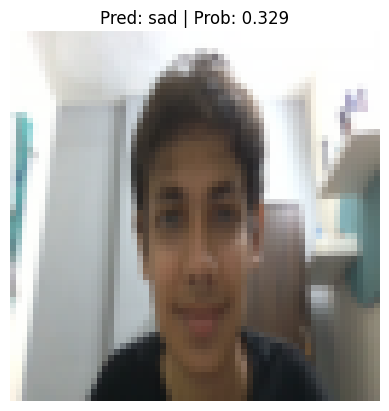

In [33]:
pred_and_plot_image(model=model_1,
                    image_path=str("happy.jpg"),
                    class_names=class_names,
                    transform=pred_transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.06308561..1.0000002].


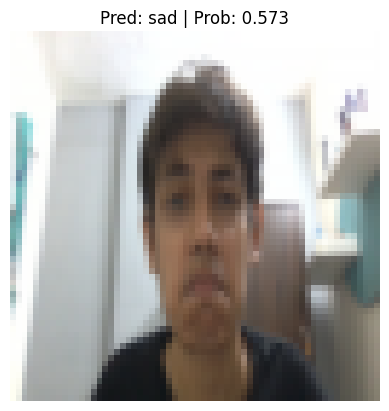

In [34]:
pred_and_plot_image(model=model_1,
                    image_path=str("sad.jpg"),
                    class_names=class_names,
                    transform=pred_transform)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07635623..1.0000002].


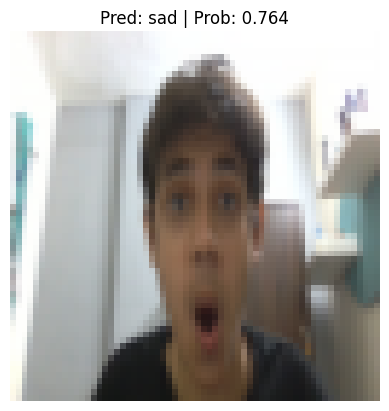

In [35]:
pred_and_plot_image(model=model_1,
                    image_path=str("surprised.jpg"),
                    class_names=class_names,
                    transform=pred_transform)